In [1]:
import pandas as pd
import requests
import math
import matplotlib.pyplot as plt

In [45]:
MAX_RESULTS_PER_PAGE = 200
BASE_URL = 'https://api.openalex.org/works?search='
keywords_gm = '(("gut microbiome") OR ("gut microbiota") OR ("gut metagenome")) AND ("shotgun sequencing") AND (("database") OR ("dataset"))'
keywords_vm = '(("vaginal microbiome") OR ("vaginal microbiota") OR ("vaginal metagenome")) AND ("shotgun sequencing") AND (("database") OR ("dataset"))'

In [46]:
def get_request(url: str):
    """Returns metadata and results of a OpenAlex API query

    Args:
        url (str): query for OpenAlex API

    Returns:
        dict: Combined metadata from all pages
        list: Combined results from all pages
    """
    all_results = []
    current_page = 1
    total_pages = None

    while True:
        paginated_url = f"{url}&page={current_page}"
        
        response = requests.get(paginated_url)
        
        if response.status_code == 200:
            data = response.json()
            if current_page == 1:
                meta = data['meta']
                total_pages = math.ceil(meta['count'] / MAX_RESULTS_PER_PAGE)
            
            results = data['results']    
            all_results.extend(results) 
                
            if current_page >= total_pages:
                break
            
            current_page += 1
            
        else:
            print(f"Error: {response.status_code}")
            break
    
    return meta, all_results

In [47]:
query_gm = f'{BASE_URL}{keywords_gm}&per-page={MAX_RESULTS_PER_PAGE}'
query_vm = f'{BASE_URL}{keywords_vm}&per-page={MAX_RESULTS_PER_PAGE}'

In [48]:
meta_gm, reports_gm = get_request(query_gm)
meta_vm, reports_vm = get_request(query_vm)

In [49]:
meta_gm

{'count': 2884,
 'db_response_time_ms': 1432,
 'page': 1,
 'per_page': 200,
 'groups_count': None}

In [50]:
meta_vm

{'count': 219,
 'db_response_time_ms': 222,
 'page': 1,
 'per_page': 200,
 'groups_count': None}

In [51]:
columns_to_keep = ['doi','title','relevance_score', 'publication_year', 'publication_date', 'cited_by_count']
result_df_gm = pd.json_normalize(reports_gm)[columns_to_keep]
result_df_vm = pd.json_normalize(reports_vm)[columns_to_keep]

In [52]:
result_df_gm.head()

,doi,title,relevance_score,publication_year,publication_date,cited_by_count
0,https://doi.org/10.1038/nature05414,An obesity-associated gut microbiome with incr...,346.38570,2006,2006-12-01,10919
1,https://doi.org/10.1038/nature07540,A core gut microbiome in obese and lean twins,248.62334,2008,2008-11-30,7274
2,https://doi.org/10.1038/nature11450,A metagenome-wide association study of gut mic...,221.47070,2012,2012-09-25,5718
3,https://doi.org/10.3390/nu12010071,Varied Pathways of Infant Gut-Associated Bifid...,221.03151,2019,2019-12-26,157
4,https://doi.org/10.1371/journal.pone.0155362,Colorectal Cancer and the Human Gut Microbiome...,219.50099,2016,2016-05-12,270


In [53]:
result_df_vm.head()

,doi,title,relevance_score,publication_year,publication_date,cited_by_count
0,https://doi.org/10.1038/nmeth.2066,Metagenomic microbial community profiling usin...,111.223990,2012,2012-06-10,1630
1,https://doi.org/10.1186/s40168-018-0605-2,Simple statistical identification and removal ...,76.710990,2018,2018-12-01,2038
2,https://doi.org/10.1101/gr.096651.109,The NIH Human Microbiome Project,72.793076,2009,2009-10-09,1881
3,https://doi.org/10.1038/nature11553,Genomic approaches to studying the human micro...,42.841946,2012,2012-09-01,493
4,https://doi.org/10.1101/2020.05.05.079996,Optimal protocols for sequence-based character...,39.642060,2020,2020-05-07,1


In [57]:
n_original = meta_gm['count']
print(f"n original (gm): {n_original}")

result_df_gm = result_df_gm[~result_df_gm.duplicated(subset=['doi'])]
print(f"n after removing duplicates doi (gm): {len(result_df_gm)}")

result_df_gm = result_df_gm[result_df_gm['cited_by_count']>0]
print(f"n after filtering citations > 0 (gm): {len(result_df_gm)}")

n original (gm): 2884
n after removing duplicates doi (gm): 2871
n after filtering citations > 0 (gm): 2408


In [59]:
n_original = meta_vm['count']
print(f"n original (vm): {n_original}")

result_df_vm = result_df_vm[~result_df_vm.duplicated(subset=['doi'])]
print(f"n after removing duplicates doi (vm): {len(result_df_vm)}")

result_df_vm = result_df_vm[result_df_vm['cited_by_count']>0]
print(f"n after filtering citations > 0 (vm): {len(result_df_vm)}")

n original (vm): 219
n after removing duplicates doi (vm): 218
n after filtering citations > 0 (vm): 188


In [60]:
result_df_gm.head()

,doi,title,relevance_score,publication_year,publication_date,cited_by_count
0,https://doi.org/10.1038/nature05414,An obesity-associated gut microbiome with incr...,346.38570,2006,2006-12-01,10919
1,https://doi.org/10.1038/nature07540,A core gut microbiome in obese and lean twins,248.62334,2008,2008-11-30,7274
2,https://doi.org/10.1038/nature11450,A metagenome-wide association study of gut mic...,221.47070,2012,2012-09-25,5718
3,https://doi.org/10.3390/nu12010071,Varied Pathways of Infant Gut-Associated Bifid...,221.03151,2019,2019-12-26,157
4,https://doi.org/10.1371/journal.pone.0155362,Colorectal Cancer and the Human Gut Microbiome...,219.50099,2016,2016-05-12,270


In [61]:
result_df_vm.head()

,doi,title,relevance_score,publication_year,publication_date,cited_by_count
0,https://doi.org/10.1038/nmeth.2066,Metagenomic microbial community profiling usin...,111.223990,2012,2012-06-10,1630
1,https://doi.org/10.1186/s40168-018-0605-2,Simple statistical identification and removal ...,76.710990,2018,2018-12-01,2038
2,https://doi.org/10.1101/gr.096651.109,The NIH Human Microbiome Project,72.793076,2009,2009-10-09,1881
3,https://doi.org/10.1038/nature11553,Genomic approaches to studying the human micro...,42.841946,2012,2012-09-01,493
4,https://doi.org/10.1101/2020.05.05.079996,Optimal protocols for sequence-based character...,39.642060,2020,2020-05-07,1


In [116]:
result_df_gm.to_csv('openalex_initialsearch_gm.csv', index=False)
result_df_gm.to_csv('openalex_initialsearch_vm.csv', index=False)

## Summary Stats

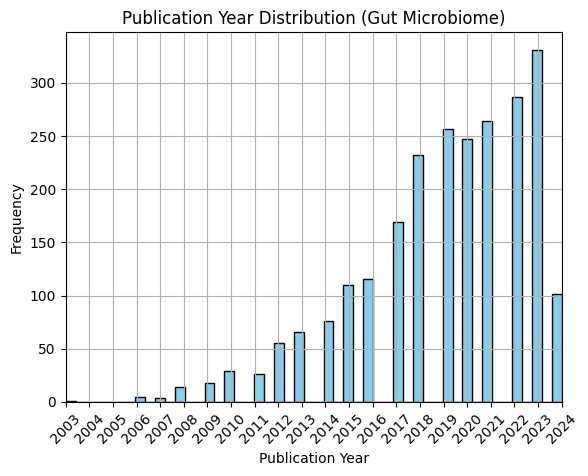

In [64]:
result_df_gm['publication_year'].hist(bins=50, color='skyblue', edgecolor='black')

# Set titles and labels
plt.title('Publication Year Distribution (Gut Microbiome)')
plt.xlabel('Publication Year')
plt.ylabel('Frequency')

# Adjust the number of ticks on the x-axis
plt.xticks(ticks=range(result_df_gm['publication_year'].min(), result_df_gm['publication_year'].max() + 1, 1), rotation=45)
plt.xlim(result_df_gm['publication_year'].min(),2024)

# Show the plot
plt.show()

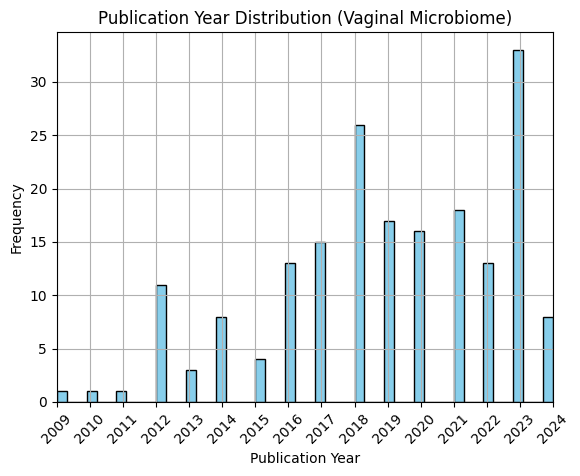

In [65]:
result_df_vm['publication_year'].hist(bins=50, color='skyblue', edgecolor='black')

# Set titles and labels
plt.title('Publication Year Distribution (Vaginal Microbiome)')
plt.xlabel('Publication Year')
plt.ylabel('Frequency')

# Adjust the number of ticks on the x-axis
plt.xticks(ticks=range(result_df_vm['publication_year'].min(), result_df_vm['publication_year'].max() + 1, 1), rotation=45)
plt.xlim(result_df_vm['publication_year'].min(),2024)

# Show the plot
plt.show()

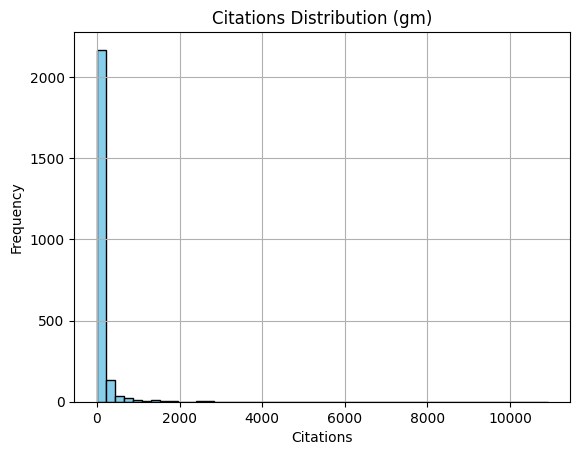

In [63]:
result_df_gm['cited_by_count'].hist(bins=50, color='skyblue', edgecolor='black')

# Set titles and labels
plt.title('Citations Distribution (gm)')
plt.xlabel('Citations')
plt.ylabel('Frequency')

# Show the plot
plt.show()

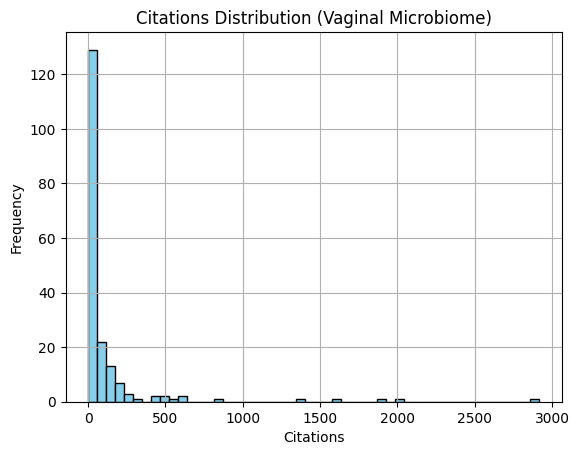

In [66]:
result_df_vm['cited_by_count'].hist(bins=50, color='skyblue', edgecolor='black')

# Set titles and labels
plt.title('Citations Distribution (Vaginal Microbiome)')
plt.xlabel('Citations')
plt.ylabel('Frequency')

# Show the plot
plt.show()